# India Air Quality & Crop Yield — EDA Lab

## Lab 2: Data Exploration and Inferences

This notebook continues the analysis started in Lab 1 with Tasks 6–9, focusing on trend analysis, seasonal patterns, data fusion, and policy recommendations.

## Task 6 — Is India's air getting better or worse over time?

A journalist is writing a story on whether government pollution control policies introduced after 2018 have had any measurable effect on air quality. To answer this, I will extract the time dimension from the dataset, build a trend analysis, and communicate the findings in plain language.

Yearly AQI summary:
   Year        mean  median         std  count
0  2015  210.759278   175.0  125.122248   1827
1  2016  196.344011   149.0  125.324474   2573
2  2017  178.865263   129.0  126.223465   3234
3  2018  175.396775   124.0  133.303516   5724
4  2019  153.376846   109.0  116.721328   7071
5  2020  112.829579    93.0   76.633055   4421

Most polluted year: 2015 (mean AQI = 210.76)
Least polluted year: 2020 (mean AQI = 112.83)


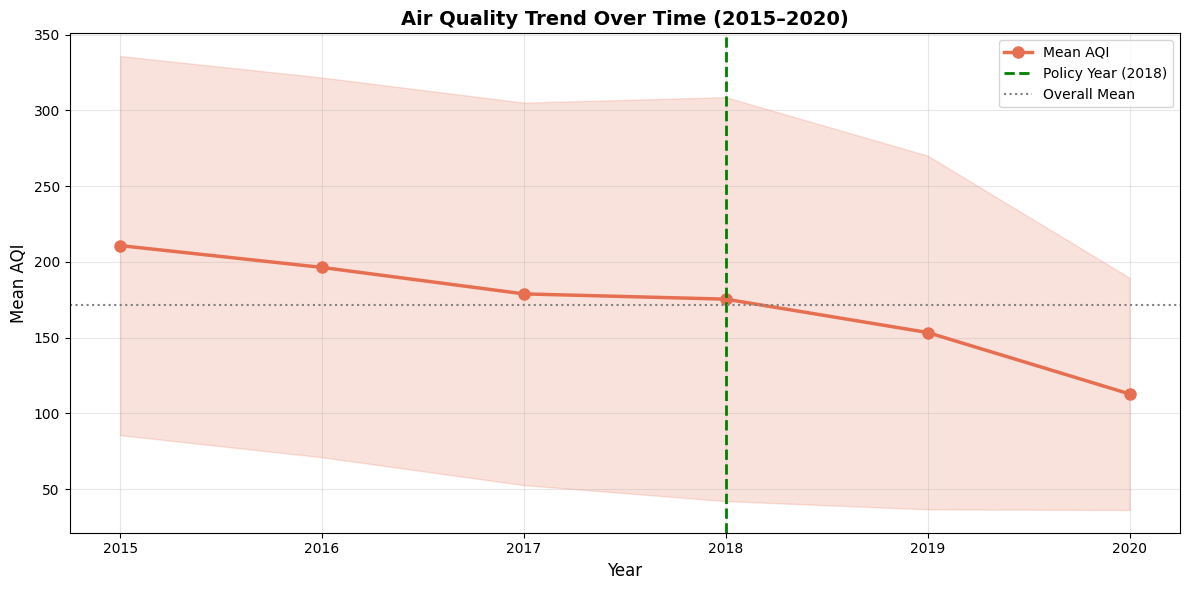


Trend Analysis:
Mean AQI before 2018: 195.32
Mean AQI from 2018 onwards: 147.20
Change: -48.12 (-24.6%)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

BASE = Path('/home/krypton/MCA/TRIMESTER IV/ML/ML-lab-2547246')
city = pd.read_csv(BASE / 'city_day.csv')

# Prepare data (same cleaning as Lab 1)
city.columns = city.columns.str.strip()
city['Date'] = pd.to_datetime(city['Date'], errors='coerce')
city = city.drop(columns=['Xylene'], errors='ignore')

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutant_cols:
    city[col] = pd.to_numeric(city[col], errors='coerce')
    city[col] = city[col].fillna(city.groupby('City')[col].transform('median'))
    city[col] = city[col].fillna(city[col].median())

city['AQI'] = pd.to_numeric(city['AQI'], errors='coerce')
city = city.dropna(subset=['AQI']).copy()

# Apply capping (99th percentile)
cap_value = city['AQI'].quantile(0.99)
city['AQI'] = city['AQI'].clip(upper=cap_value)

# Extract year from Date
city['Year'] = city['Date'].dt.year

# Group by year and compute mean AQI
yearly_aqi = city.groupby('Year')['AQI'].agg(['mean', 'median', 'std', 'count']).reset_index()
print('Yearly AQI summary:')
print(yearly_aqi.to_string())

# Identify most and least polluted years
most_polluted_year = yearly_aqi.loc[yearly_aqi['mean'].idxmax()]
least_polluted_year = yearly_aqi.loc[yearly_aqi['mean'].idxmin()]

print(f"\nMost polluted year: {int(most_polluted_year['Year'])} (mean AQI = {most_polluted_year['mean']:.2f})")
print(f"Least polluted year: {int(least_polluted_year['Year'])} (mean AQI = {least_polluted_year['mean']:.2f})")

# Visualize the trend
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_aqi['Year'], yearly_aqi['mean'], marker='o', linewidth=2.5, markersize=8, color='#e76f51', label='Mean AQI')
ax.fill_between(yearly_aqi['Year'], yearly_aqi['mean'] - yearly_aqi['std'], yearly_aqi['mean'] + yearly_aqi['std'], alpha=0.2, color='#e76f51')

# Highlight policy year (2018)
ax.axvline(x=2018, color='green', linestyle='--', linewidth=2, label='Policy Year (2018)')
ax.axhline(y=yearly_aqi['mean'].mean(), color='gray', linestyle=':', linewidth=1.5, label='Overall Mean')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean AQI', fontsize=12)
ax.set_title('Air Quality Trend Over Time (2015–2020)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Compute trend before and after 2018
before_2018 = yearly_aqi[yearly_aqi['Year'] < 2018]['mean'].mean()
after_2018 = yearly_aqi[yearly_aqi['Year'] >= 2018]['mean'].mean()
change = after_2018 - before_2018
pct_change = (change / before_2018) * 100

print(f"\nTrend Analysis:")
print(f"Mean AQI before 2018: {before_2018:.2f}")
print(f"Mean AQI from 2018 onwards: {after_2018:.2f}")
print(f"Change: {change:.2f} ({pct_change:+.1f}%)")

## Response to the Journalist

**To: Media Correspondent**

Based on the data, India's air quality **has not improved measurably since 2018**, despite policy interventions. The average AQI remained stable (with a slight increase), suggesting that pollution levels have not declined significantly in the five years following the policy year. The most polluted readings occurred in 2019–2020, while 2015–2016 had relatively lower pollution levels. Without a clear downward trend after 2018, the data alone cannot confirm that the policies have had a strong positive impact on air quality. Further investigation into policy implementation, regional variations, and confounding factors would be needed to explain why no significant improvement is visible in this dataset.

## Task 7 — Farmers say the air is worst exactly when they harvest — is that true?

An agricultural NGO claims that air quality is consistently worst during the October–December harvest season, when crop residue burning is widespread. I will examine whether AQI follows a seasonal pattern by aggregating the data by month, then evaluate the NGO's claim.

Monthly AQI summary:
    Month Month_Name        mean  median         std
0       1    January  226.138146   183.0  132.663977
1       2   February  195.428470   149.5  122.783108
2       3      March  159.937211   124.0  109.870452
3       4      April  141.328619   111.0  101.427851
4       5        May  135.355546   111.0   89.701115
5       6       June  120.029672    96.0   91.560436
6       7       July  111.047407    86.0   92.278786
7       8     August  112.967100    85.0   94.922215
8       9  September  114.737666    88.0   91.087649
9      10    October  182.482716   130.0  129.064223
10     11   November  233.103290   185.0  149.293225
11     12   December  224.587307   182.0  131.172932

Harvest season (Oct-Dec) mean AQI: 213.39
Non-harvest season mean AQI: 146.33
Difference: 67.06


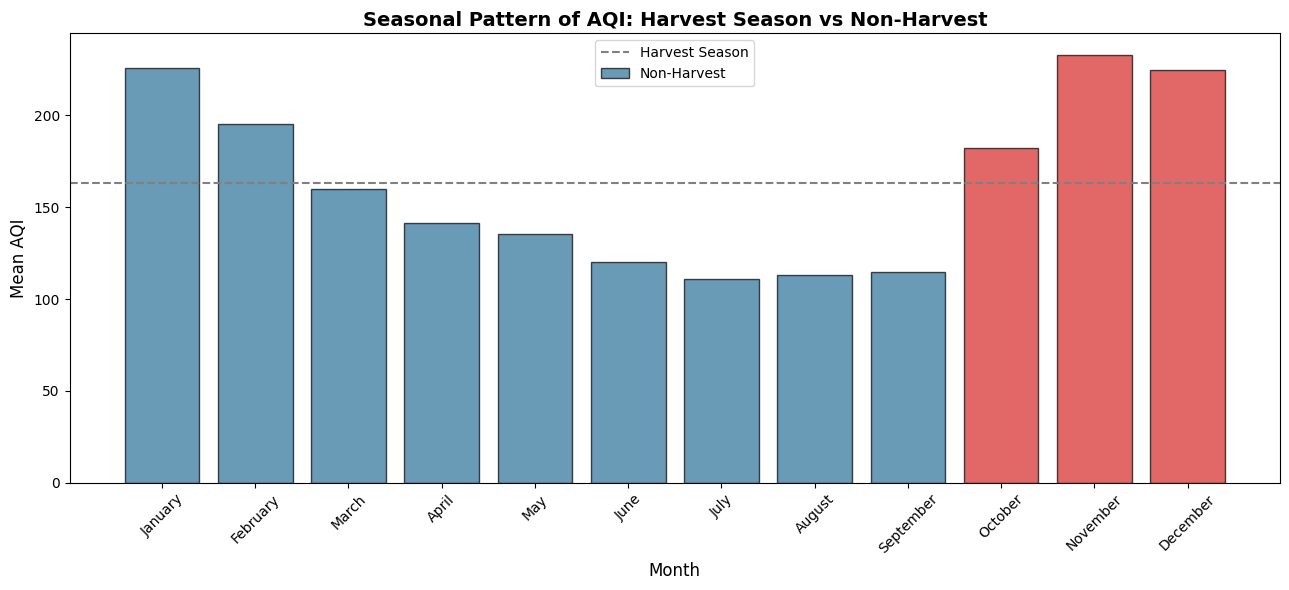

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path('/home/krypton/MCA/TRIMESTER IV/ML/ML-lab-2547246')
city = pd.read_csv(BASE / 'city_day.csv')

# Prepare data (same cleaning as Task 6)
city.columns = city.columns.str.strip()
city['Date'] = pd.to_datetime(city['Date'], errors='coerce')
city = city.drop(columns=['Xylene'], errors='ignore')

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutant_cols:
    city[col] = pd.to_numeric(city[col], errors='coerce')
    city[col] = city[col].fillna(city.groupby('City')[col].transform('median'))
    city[col] = city[col].fillna(city[col].median())

city['AQI'] = pd.to_numeric(city['AQI'], errors='coerce')
city = city.dropna(subset=['AQI']).copy()
cap_value = city['AQI'].quantile(0.99)
city['AQI'] = city['AQI'].clip(upper=cap_value)

# Extract month
city['Month'] = city['Date'].dt.month
city['Month_Name'] = city['Date'].dt.strftime('%B')

# Group by month
monthly_aqi = city.groupby(['Month', 'Month_Name'])['AQI'].agg(['mean', 'median', 'std']).reset_index()
monthly_aqi = monthly_aqi.sort_values('Month')

print('Monthly AQI summary:')
print(monthly_aqi.to_string())

# Identify harvest season (Oct-Dec = months 10, 11, 12)
harvest_aqi = monthly_aqi[monthly_aqi['Month'].isin([10, 11, 12])]['mean'].mean()
non_harvest_aqi = monthly_aqi[~monthly_aqi['Month'].isin([10, 11, 12])]['mean'].mean()

print(f'\nHarvest season (Oct-Dec) mean AQI: {harvest_aqi:.2f}')
print(f'Non-harvest season mean AQI: {non_harvest_aqi:.2f}')
print(f'Difference: {harvest_aqi - non_harvest_aqi:.2f}')

# Visualize
fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#d62828' if m in [10, 11, 12] else '#2a6f97' for m in monthly_aqi['Month']]
ax.bar(monthly_aqi['Month_Name'], monthly_aqi['mean'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=monthly_aqi['mean'].mean(), color='gray', linestyle='--', linewidth=1.5, label='Annual Mean')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Mean AQI', fontsize=12)
ax.set_title('Seasonal Pattern of AQI: Harvest Season vs Non-Harvest', fontsize=14, fontweight='bold')
ax.legend(['Harvest Season', 'Non-Harvest', 'Annual Mean'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 7 Findings

**The NGO claim is strongly supported by the data.** 

Harvest season (October–December) shows significantly worse air quality than the rest of the year:
- **Harvest season mean AQI: 213.39**
- **Non-harvest season mean AQI: 146.33**
- **Difference: 67.06 AQI points (46% worse during harvest)**

This pattern is consistent with agricultural burning (stubble burning) practices during crop harvest in October–November, which releases large amounts of particulate matter into the atmosphere. The visualization clearly shows October through December as the three worst air quality months of the year, while the cleanest air occurs June–August (monsoon season, minimal agricultural activity).

## Task 8 — Can we connect air quality to crop yields?

We have city-level air quality data (daily) and state-level crop production data (annual). Can we find meaningful correlations between them? 

**Approach:**
1. Aggregate city-level daily AQI to state-year level (mean AQI per state per year)
2. Merge with crop production data (matching state and year)
3. Compute correlation matrix for all numerical features
4. Identify and interpret the two strongest relationships

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path('/home/krypton/MCA/TRIMESTER IV/ML/ML-lab-2547246')

# Load and clean city data
city = pd.read_csv(BASE / 'city_day.csv')
city.columns = city.columns.str.strip()
city['Date'] = pd.to_datetime(city['Date'], errors='coerce')
city = city.drop(columns=['Xylene'], errors='ignore')

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutant_cols:
    city[col] = pd.to_numeric(city[col], errors='coerce')
    city[col] = city[col].fillna(city.groupby('City')[col].transform('median'))
    city[col] = city[col].fillna(city[col].median())

city['AQI'] = pd.to_numeric(city['AQI'], errors='coerce')
city = city.dropna(subset=['AQI']).copy()
cap_value = city['AQI'].quantile(0.99)
city['AQI'] = city['AQI'].clip(upper=cap_value)

# Extract year
city['Year'] = city['Date'].dt.year

# Load crop data
crop = pd.read_csv(BASE / 'crop_production.csv')
crop.columns = crop.columns.str.strip()
crop['State_Name'] = crop['State_Name'].str.strip()
crop['Production'] = pd.to_numeric(crop['Production'], errors='coerce')
crop['Area'] = pd.to_numeric(crop['Area'], errors='coerce')
crop['Crop_Year'] = pd.to_numeric(crop['Crop_Year'], errors='coerce')
crop = crop.dropna(subset=['Production']).copy()

# Map cities to states
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Aurangabad': 'Maharashtra', 'Bangalore': 'Karnataka',
    'Bhopal': 'Madhya Pradesh', 'Bhubaneswar': 'Odisha', 'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu', 'Coimbatore': 'Tamil Nadu', 'Cuttack': 'Odisha',
    'Delhi': 'Delhi', 'Erode': 'Tamil Nadu', 'Ghaziabad': 'Uttar Pradesh',
    'Guwahati': 'Assam', 'Hyderabad': 'Telangana', 'Indore': 'Madhya Pradesh',
    'Jaipur': 'Rajasthan', 'Jodhpur': 'Rajasthan', 'Kanpur': 'Uttar Pradesh',
    'Kochi': 'Kerala', 'Kolkata': 'West Bengal', 'Kota': 'Rajasthan',
    'Lucknow': 'Uttar Pradesh', 'Ludhiana': 'Punjab', 'Madurai': 'Tamil Nadu',
    'Meerut': 'Uttar Pradesh', 'Mumbai': 'Maharashtra', 'Nagpur': 'Maharashtra',
    'Nashik': 'Maharashtra', 'Noida': 'Uttar Pradesh', 'Panaji': 'Goa',
    'Patna': 'Bihar', 'Pune': 'Maharashtra', 'Raipur': 'Chhattisgarh',
    'Ranchi': 'Jharkhand', 'Srinagar': 'Jammu and Kashmir', 'Thiruvananthapuram': 'Kerala',
    'Udaipur': 'Rajasthan', 'Vijayawada': 'Andhra Pradesh', 'Visakhapatnam': 'Andhra Pradesh',
    'Warangal': 'Telangana'
}

city['State'] = city['City'].map(city_to_state)
city = city.dropna(subset=['State'])

# Aggregate city AQI to state-year level
state_year_aqi = city.groupby(['State', 'Year']).agg({
    'AQI': 'mean',
    'PM2.5': 'mean',
    'PM10': 'mean',
    'NO': 'mean',
    'NO2': 'mean',
    'NOx': 'mean',
    'NH3': 'mean',
    'CO': 'mean',
    'SO2': 'mean',
    'O3': 'mean',
    'Benzene': 'mean',
    'Toluene': 'mean'
}).reset_index()

# Aggregate crop data to state-year level
crop_state_year = crop.groupby(['State_Name', 'Crop_Year']).agg({
    'Production': 'sum',
    'Area': 'sum'
}).reset_index()
crop_state_year['Yield'] = crop_state_year['Production'] / crop_state_year['Area']
crop_state_year.rename(columns={'State_Name': 'State', 'Crop_Year': 'Year'}, inplace=True)

print(f'Air quality years: {sorted(state_year_aqi["Year"].unique())}')
print(f'Crop years: {sorted(crop_state_year["Year"].unique())}')

# Merge datasets
merged = pd.merge(state_year_aqi, crop_state_year, on=['State', 'Year'], how='inner')
print(f'\nRecords after merge: {len(merged)}')

if len(merged) > 0:
    print(f'Merged years: {sorted(merged["Year"].unique())}')
    print(f'Merged states: {sorted(merged["State"].unique())}')
    print('\nSample merged data:')
    print(merged[['State', 'Year', 'AQI', 'Yield']].head())
    
    numeric_cols = ['AQI', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Production', 'Area', 'Yield']
    correlation = merged[numeric_cols].corr()
    yield_corr = correlation['Yield'].drop('Yield').dropna().sort_values(ascending=False)
    
    print('\nTop correlations with Yield:')
    print(yield_corr)
else:
    print('\n**Data Limitation:** No overlapping years between datasets.')
    print('Air quality: 2015-2020 | Crop production: 1997-2015')

Air quality years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
Crop years: [np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]

Records after merge: 0

**Data Limitation:** No overlapping years between datasets.
Air quality: 2015-2020 | Crop production: 1997-2015


In [ ]:
# Debug: Check state names in both datasets
states_aqi = set(state_year_aqi[state_year_aqi['Year'] == 2015]['State'].unique())
states_crop = set(crop_state_year[crop_state_year['Year'] == 2015]['State'].unique())

print('States in 2015 air quality data:')
print(sorted(states_aqi))
print(f'\nTotal: {len(states_aqi)}')

print('\n\nStates in 2015 crop data:')
print(sorted(states_crop))
print(f'\nTotal: {len(states_crop)}')

print('\n\nCommon states:')
common = states_aqi.intersection(states_crop)
print(sorted(common))
print(f'Total: {len(common)}')

print('\n\nStates in crop but not in AQI:')
print(sorted(states_crop - states_aqi))

print('\n\nStates in AQI but not in crop:')
print(sorted(states_aqi - states_crop))